**Этот ноутбук является упражнением из курса [Введение в глубокое обучение](https://www.kaggle.com/learn/intro-to-deep-learning). Вы можете обратиться к учебному пособию по [этой ссылке](https://www.kaggle.com/ryanholbrook/binary-classification).**

---


# Введение #

В этом упражнении вы построите модель для прогнозирования отмен бронирования в отелях с помощью бинарного классификатора.

In [1]:
# Настройка графиков
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
# Установка параметров Matplotlib по умолчанию
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('animation', html='html5')

Сначала загрузим набор данных *Hotel Cancellations* (Отмены бронирования отелей).

In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

hotel = pd.read_csv('./data/hotel.csv')

X = hotel.copy()
y = X.pop('is_canceled')

X['arrival_date_month'] = \
    X['arrival_date_month'].map(
        {'January':1, 'February': 2, 'March':3,
         'April':4, 'May':5, 'June':6, 'July':7,
         'August':8, 'September':9, 'October':10,
         'November':11, 'December':12}
    )

features_num = [
    "lead_time", "arrival_date_week_number",
    "arrival_date_day_of_month", "stays_in_weekend_nights",
    "stays_in_week_nights", "adults", "children", "babies",
    "is_repeated_guest", "previous_cancellations",
    "previous_bookings_not_canceled", "required_car_parking_spaces",
    "total_of_special_requests", "adr",
]
features_cat = [
    "hotel", "arrival_date_month", "meal",
    "market_segment", "distribution_channel",
    "reserved_room_type", "deposit_type", "customer_type",
]

transformer_num = make_pipeline(
    SimpleImputer(strategy="constant"), # есть несколько пропущенных значений
    StandardScaler(),
)
transformer_cat = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="NA"),
    OneHotEncoder(handle_unknown='ignore'),
)

preprocessor = make_column_transformer(
    (transformer_num, features_num),
    (transformer_cat, features_cat),
)

# stratify - гарантирует равномерное представление классов в разбивке
X_train, X_valid, y_train, y_valid = \
    train_test_split(X, y, stratify=y, train_size=0.75)

X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)

input_shape = [X_train.shape[1]]

# 1) Определение модели #

На этот раз мы будем использовать модель, содержащую как слои пакетной нормализации, так и слои исключения (dropout). Для удобства чтения мы разбили диаграмму на блоки, но вы можете определять её слой за слоем как обычно.

Определите модель с архитектурой, представленной на этой диаграмме:

<figure style="padding: 1em;">
<img src="https://storage.googleapis.com/kaggle-media/learn/images/V04o59Z.png" width="400" alt="Диаграмма архитектуры сети: BatchNorm, Dense, BatchNorm, Dropout, Dense, BatchNorm, Dropout, Dense.">
<figcaption style="textalign: center; font-style: italic"><center>Диаграмма бинарного классификатора.</center></figcaption>
</figure>


In [7]:
from tensorflow import keras
from tensorflow.keras import layers

# ВАШ КОД ЗДЕСЬ: определите модель, представленную на диаграмме
model = keras.Sequential([
    layers.BatchNormalization(input_shape=input_shape),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
])

c:\Users\iOlvik\Documents\1_Dev\Work\ML_training\venv\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:181: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# 2) Добавление оптимизатора, функции потерь и метрики #

Теперь скомпилируйте модель с оптимизатором Adam и бинарными версиями функции потерь cross-entropy и метрики точности.

In [8]:
# ВАШ КОД ЗДЕСЬ
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)



In [ ]:
# Строки ниже дадут вам подсказку или код решения
#q_2.hint()
#q_2.solution()

Наконец, выполните эту ячейку для обучения модели и просмотра кривых обучения. Обучение может занять около 60–70 эпох, что может занять минуту или две.

Epoch 1/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - binary_accuracy: 0.7703 - loss: 0.4860 - val_binary_accuracy: 0.8062 - val_loss: 0.4394
Epoch 2/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.8011 - loss: 0.4229 - val_binary_accuracy: 0.8140 - val_loss: 0.4031
Epoch 3/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.8080 - loss: 0.4093 - val_binary_accuracy: 0.8161 - val_loss: 0.3986
Epoch 4/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.8123 - loss: 0.4013 - val_binary_accuracy: 0.8185 - val_loss: 0.3914
Epoch 5/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.8151 - loss: 0.3954 - val_binary_accuracy: 0.8197 - val_loss: 0.3859
Epoch 6/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.8177 - loss: 0.3923 - val_binary_accuracy: 0.8232 - val_loss: 0.3847
Epoch 7/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.8195 - loss: 0.3883 - val_binary_accuracy: 0.8259 - val_loss: 0.3805

<Axes: title={'center': 'Точность'}>

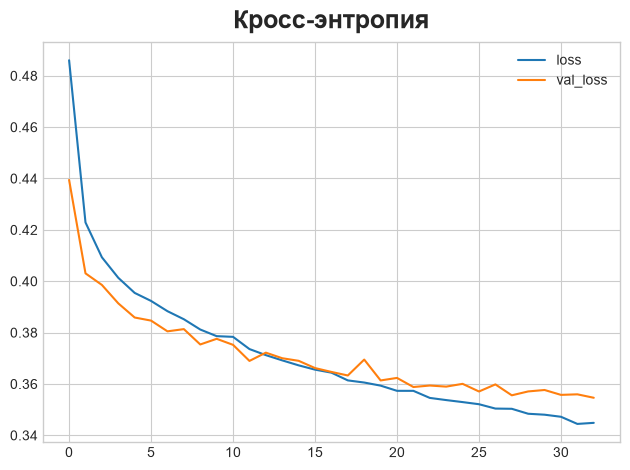

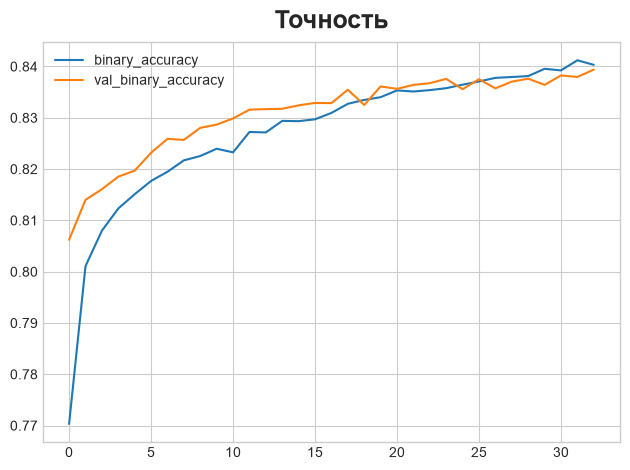

In [9]:
early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=512,
    epochs=200,
    callbacks=[early_stopping],
)

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot(title="Кросс-энтропия")
history_df.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot(title="Точность")

# 3) Обучение и оценка #

Что вы думаете о кривых обучения? Похоже ли, что модель недообучилась или переобучилась? Была ли кросс-энтропийная потеря хорошей заменой точности?

In [ ]:
# Просмотрите решение (Выполните эту ячейку, чтобы получить зачёт!)
q_3.check()

# Заключение #

Поздравляем! Вы завершили курс Kaggle *Введение в глубокое обучение*!

С вашими новыми навыками вы готовы взяться за более продвинутые приложения, такие как компьютерное зрение и классификация тональности текстов. Что бы вы хотели сделать дальше?

Почему бы не попробовать одно из наших соревнований *Getting Started*?

- Классифицируйте изображения с помощью TPU в [**Petals to the Metal**](https://www.kaggle.com/c/tpu-getting-started)
- Создавайте искусство с помощью GAN в [**I'm Something of a Painter Myself**](https://www.kaggle.com/c/gan-getting-started)
- Классифицируйте твиты в [**Real or Not? NLP with Disaster Tweets**](https://www.kaggle.com/c/nlp-getting-started)
- Определяйте противоречия и логическое следование в [**Contradictory, My Dear Watson**](https://www.kaggle.com/c/contradictory-my-dear-watson)

До новых встреч, каглеры!

---

*Есть вопросы или комментарии? Посетите [форум обсуждения курса](https://www.kaggle.com/learn/intro-to-deep-learning/discussion), чтобы пообщаться с другими учащимися.*